In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [3]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches, predict_ann_in_batches

In [4]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "DBP_RELIEFF_train.csv")
val_path   = os.path.join(DATA_DIR, "DBP_RELIEFF_val.csv")
test_path  = os.path.join(DATA_DIR, "DBP_RELIEFF_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (263103, 16)
Val:   (33223, 16)
Test:  (33347, 16)


In [5]:
TARGET = "DBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (263103, 15)
y_train: (263103,)
X_val:   (33223, 15)
y_val:   (33223,)
X_test:  (33347, 15)
y_test:  (33347,)


In [6]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/data/DBP_RELIEFF_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(2928374, 17)
   vpg_mean  apg_mean  apg_zero_crossing_rate  apg_median  vpg_median  \
0 -0.127401 -1.422879               -0.339146   -1.598747   -2.880214   
1  0.085049  1.402739               -0.186419   -1.197357   -3.115539   
2 -2.313259 -0.413076               -0.339146   -1.534092   -2.930166   
3  2.014257  0.555521                0.959027   -1.384103   -2.791438   
4  0.634868 -1.595798                0.500849   -1.327176   -2.948292   

   ppg_energy_variance  apg_skewness  vpg_skewness  vpg_shannon_entropy  \
0             0.983130      2.973598     -0.554263             0.068754   
1             1.032805      2.599054     -0.573270             0.333610   
2             0.636401      2.823279     -0.644623             0.399707   
3             0.921181      2.647086     -0.709170             0.474845   
4             1.145072      2.868377     -0.657449             0.371499   

   ppg_variance   ppg_std  vpg_zero_crossing_rate  ppg_kte_iqr  \
0      0.093478  0.134037     

In [7]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [8]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [9]:
print("DBP min:", y_train.min())
print("DBP max:", y_train.max())
print("DBP mean:", y_train.mean())
print("DBP std:", y_train.std())

print("DBP > 80:", np.sum(y_train > 80))
print("DBP > 90:", np.sum(y_train > 90))
print("DBP > 100:", np.sum(y_train > 100))

DBP min: 50.0
DBP max: 149.80486780343182
DBP mean: 66.41287378707464
DBP std: 10.878506659869677
DBP > 80: 29106
DBP > 90: 8829
DBP > 100: 2904


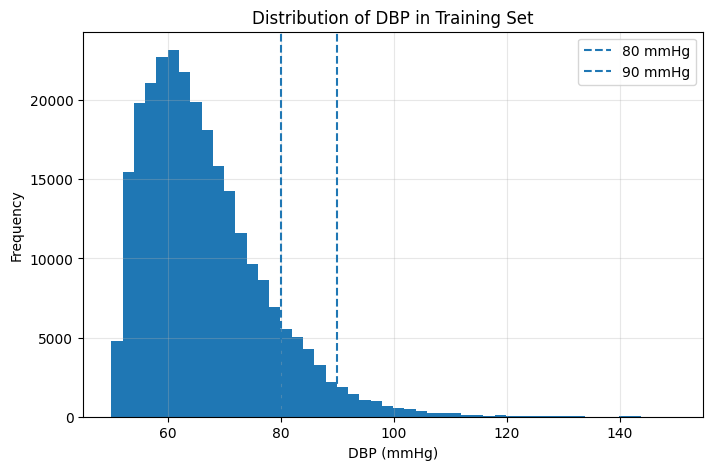

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("DBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of DBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: DBP
RMSE: 10.7720
MSE : 116.0359
R²  : 0.0711
MAE : 8.5143


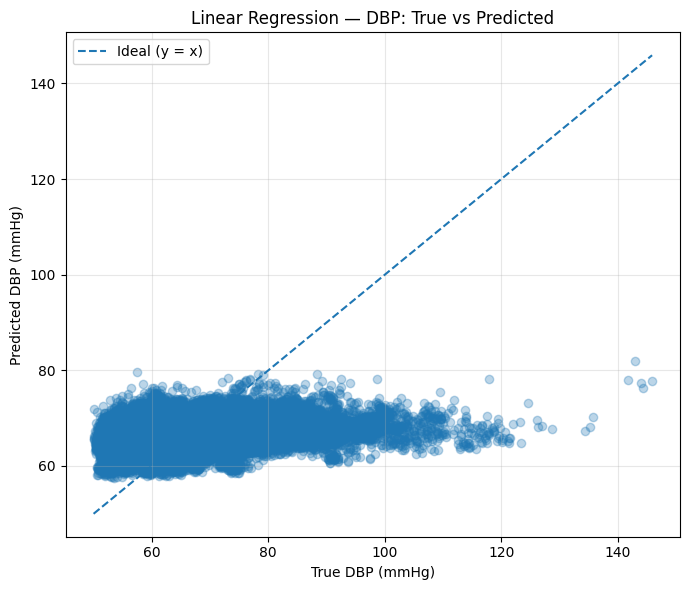

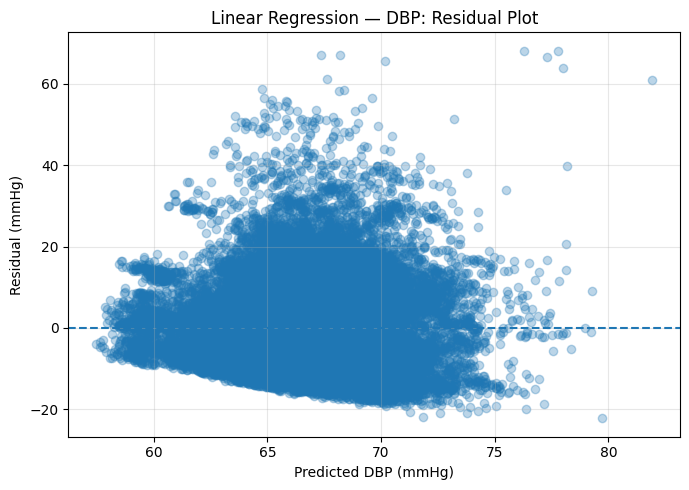

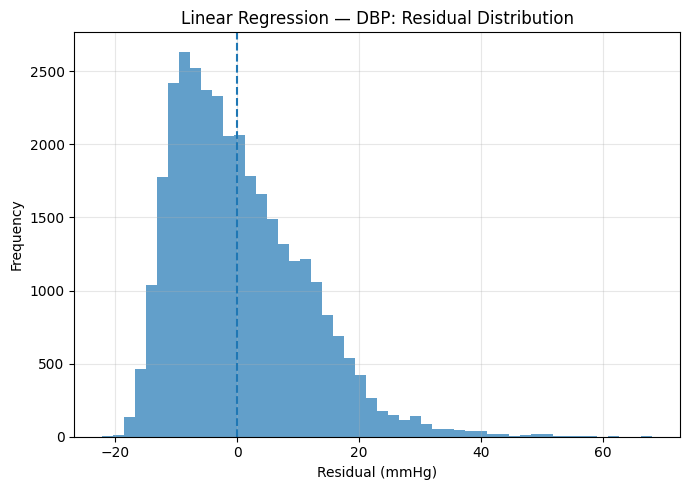

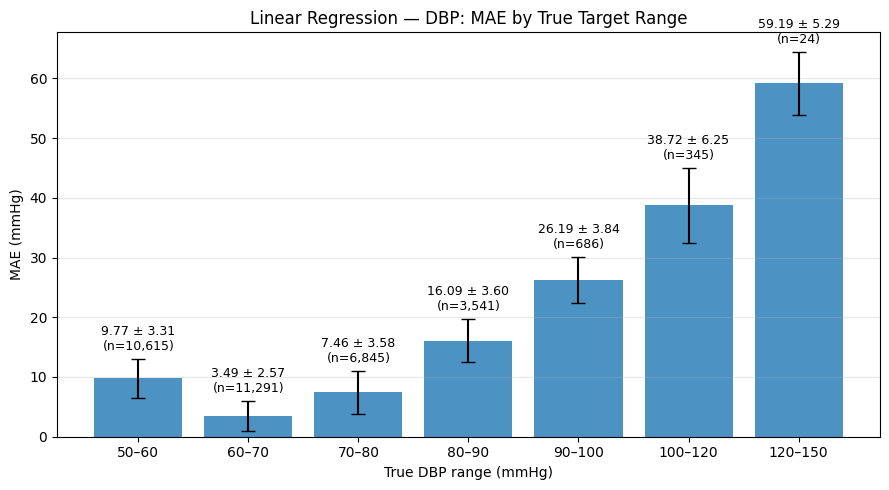

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

RMSE: 43.0558
MSE : 1853.8056
R²  : -10.4529
MAE : 20.9512


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/relieff/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


## INTERACTION LINEAR REGRESSION ##

In [ ]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

In [ ]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

In [ ]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

In [ ]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

In [ ]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

In [ ]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

In [ ]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

In [ ]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

In [ ]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

In [ ]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

In [ ]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

In [ ]:
y_pred_vitaldb = predict_ann_in_batches(
    ann_model,
    X_test_vital,
y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)